# Caso D — UCI Occupancy Detection: EDA y modelos de ML

Este notebook realiza un flujo completo para el dataset **UCI Occupancy Detection**:

1. Carga de datos de entrenamiento y test.
2. Limpieza y validación de los datos.
3. Análisis exploratorio de datos (EDA).
4. Análisis de correlaciones y relación de variables con `Occupancy`.
5. Entrenamiento de modelos de Machine Learning.
6. Evaluación comparativa contra una baseline.
7. Selección del mejor modelo y guardado de todos los modelos probados.

**Objetivo del modelo:** predecir si una sala está ocupada (`Occupancy = 1`) o no ocupada (`Occupancy = 0`) a partir de variables ambientales: temperatura, humedad, luminosidad, CO₂ y ratio de humedad.

Que están alineados con las variables de entrada del proyecto CENTINELA:
- `co2` — concentración de CO₂ (ppm) — predictor principal de ocupación
- `temperature-indoor` — temperatura interior (°C)
- `relative-humidity` — humedad relativa (%)
- `avg-sound-level` — nivel de ruido (dB)
- `luminosity` — luminosidad (lux)


## 0. Instalación de librerías

Ejecutar si faltan dependencias.

In [ ]:
# %pip install pandas numpy matplotlib scikit-learn joblib

## 1. Imports y configuración general

In [ ]:
from pathlib import Path
import warnings
import re

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

RANDOM_STATE = 42
OUTPUT_DIR_NAME = "outputs_uci_occupancy"

# Ruta local temporal. En la celda de carga de datos se redefine para guardar en Google Drive.
OUTPUT_DIR = Path(OUTPUT_DIR_NAME)
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = OUTPUT_DIR / "models"


def safe_filename(name: str) -> str:
    """Normaliza nombres para usarlos como nombres de fichero."""
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(name)).strip("_")


def ensure_output_dirs() -> None:
    """Crea las carpetas de salida necesarias."""
    for directory in [OUTPUT_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR]:
        directory.mkdir(parents=True, exist_ok=True)


def save_table(df: pd.DataFrame | pd.Series, filename: str) -> Path:
    """Guarda una tabla o serie en la carpeta de resultados del Drive."""
    ensure_output_dirs()
    path = TABLES_DIR / filename
    if isinstance(df, pd.Series):
        df.to_frame().to_csv(path, index=True)
    else:
        df.to_csv(path, index=False)
    return path


def save_figure(fig, filename: str) -> Path:
    """Guarda una figura en PNG en la carpeta de resultados del Drive."""
    ensure_output_dirs()
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return path

ensure_output_dirs()


## 2. Carga de datos

El dataset original trae tres ficheros:

- `datatraining.txt`: conjunto de entrenamiento.
- `datatest.txt`: primer conjunto de test.
- `datatest2.txt`: segundo conjunto de test.

El notebook busca estos ficheros en una ubicaión de Google Drive.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path


def find_data_dir() -> Path:
    """
    Devuelve el directorio donde están los ficheros del caso D.

    Pensado para Google Colab con Google Drive montado.
    Ruta esperada:
        /content/drive/MyDrive/simarro-cursoia/caso-d/
    """
    candidates = [
        Path("/content/drive/MyDrive/simarro-cursoia/caso-d-uci"),
        Path("/content/drive/My Drive/simarro-cursoia/caso-d-uci"),
        Path("/simarro-cursoia/caso-d-uci"),
    ]

    required_files = ["datatraining.txt", "datatest.txt", "datatest2.txt"]

    for candidate in candidates:
        if all((candidate / file).exists() for file in required_files):
            return candidate

    searched_paths = "\n".join(str(path.resolve()) for path in candidates)

    raise FileNotFoundError(
        "No se encontraron datatraining.txt, datatest.txt y datatest2.txt.\n"
        "Rutas revisadas:\n"
        f"{searched_paths}\n\n"
        "Si estás usando Google Colab, primero monta Drive con:\n"
        "from google.colab import drive\n"
        "drive.mount('/content/drive')"
    )


def load_uci_file(path: Path, split_name: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["split"] = split_name
    return df


DATA_DIR = find_data_dir()
print(f"Directorio de datos: {DATA_DIR.resolve()}")

# Todos los resultados quedan guardados dentro de Google Drive, junto a los datos del caso.
OUTPUT_DIR = DATA_DIR / OUTPUT_DIR_NAME
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = OUTPUT_DIR / "models"
ensure_output_dirs()

print(f"Directorio de resultados en Drive: {OUTPUT_DIR.resolve()}")
print(f"- Tablas: {TABLES_DIR.resolve()}")
print(f"- Figuras: {FIGURES_DIR.resolve()}")
print(f"- Modelos: {MODELS_DIR.resolve()}")

train_df = load_uci_file(DATA_DIR / "datatraining.txt", "train")
test1_df = load_uci_file(DATA_DIR / "datatest.txt", "test1")
test2_df = load_uci_file(DATA_DIR / "datatest2.txt", "test2")

full_df = pd.concat([train_df, test1_df, test2_df], ignore_index=True)

print("Train:", train_df.shape)
print("Test 1:", test1_df.shape)
print("Test 2:", test2_df.shape)
print("Dataset completo:", full_df.shape)

full_df.head()


Mounted at /content/drive
Directorio de datos: /content/drive/MyDrive/simarro-cursoia/caso-d-uci
Directorio de resultados en Drive: /content/drive/MyDrive/simarro-cursoia/caso-d-uci/outputs_uci_occupancy
- Tablas: /content/drive/MyDrive/simarro-cursoia/caso-d-uci/outputs_uci_occupancy/tables
- Figuras: /content/drive/MyDrive/simarro-cursoia/caso-d-uci/outputs_uci_occupancy/figures
- Modelos: /content/drive/MyDrive/simarro-cursoia/caso-d-uci/outputs_uci_occupancy/models
Train: (8143, 8)
Test 1: (2665, 8)
Test 2: (9752, 8)
Dataset completo: (20560, 8)


,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy,split
0,2015-02-04 17:51:00,23.1800,27.2720,426.0000,721.2500,0.0048,1,train
1,2015-02-04 17:51:59,23.1500,27.2675,429.5000,714.0000,0.0048,1,train
2,2015-02-04 17:53:00,23.1500,27.2450,426.0000,713.5000,0.0048,1,train
3,2015-02-04 17:54:00,23.1500,27.2000,426.0000,708.2500,0.0048,1,train
4,2015-02-04 17:55:00,23.1000,27.2000,426.0000,704.5000,0.0048,1,train


## 3. Revisión inicial del dataset

En esta sección se revisan columnas, tipos de datos, valores nulos, duplicados y rango temporal.

In [ ]:
print("Columnas:")
print(full_df.columns.tolist())

print("\nTipos de datos:")
display(full_df.dtypes)

print("\nNulos por columna:")
display(full_df.isna().sum())

print("\nDuplicados:", full_df.duplicated().sum())

print("\nRango temporal por partición:")
display(
    full_df.groupby("split")["date"]
    .agg(["min", "max", "count"])
    .reset_index()
)

Columnas:
['date', 'Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio', 'Occupancy', 'split']

Tipos de datos:


,0
date,datetime64[ns]
Temperature,float64
Humidity,float64
Light,float64
CO2,float64
HumidityRatio,float64
Occupancy,int64
split,object



Nulos por columna:


,0
date,0
Temperature,0
Humidity,0
Light,0
CO2,0
HumidityRatio,0
Occupancy,0
split,0



Duplicados: 0

Rango temporal por partición:


,split,min,max,count
0,test1,2015-02-02 14:19:00,2015-02-04 10:43:00,2665
1,test2,2015-02-11 14:48:00,2015-02-18 09:19:00,9752
2,train,2015-02-04 17:51:00,2015-02-10 09:33:00,8143


No se ven nulos en las variables principales.

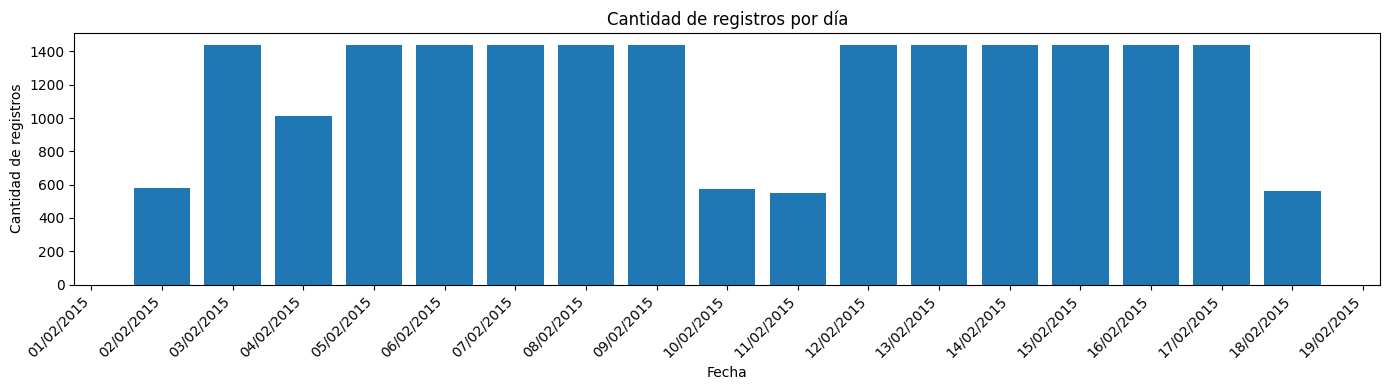

,fecha,cantidad_registros
0,2015-02-02,581
1,2015-02-03,1440
2,2015-02-04,1013
3,2015-02-05,1440
4,2015-02-06,1440
5,2015-02-07,1440
6,2015-02-08,1440
7,2015-02-09,1440
8,2015-02-10,574
9,2015-02-11,552


In [ ]:

# =========================
# Registros por día
# =========================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Asegurar formato datetime
full_df["date"] = pd.to_datetime(full_df["date"], errors="coerce")

# Cantidad de registros por día
registros_por_dia = (
    full_df
    .assign(fecha=full_df["date"].dt.floor("D"))
    .groupby("fecha")
    .size()
    .rename("cantidad_registros")
    .reset_index()
)

# Completar días faltantes entre la primera y última fecha
rango_fechas = pd.date_range(
    start=full_df["date"].min().floor("D"),
    end=full_df["date"].max().floor("D"),
    freq="D"
)

registros_por_dia = (
    registros_por_dia
    .set_index("fecha")
    .reindex(rango_fechas, fill_value=0)
    .rename_axis("fecha")
    .reset_index()
)

# Gráfico
fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(
    registros_por_dia["fecha"],
    registros_por_dia["cantidad_registros"]
)

ax.set_title("Cantidad de registros por día")
ax.set_xlabel("Fecha")
ax.set_ylabel("Cantidad de registros")

ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m/%Y"))

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
save_figure(fig, "registros_por_dia.png")
plt.show()

save_table(registros_por_dia, "registros_por_dia.csv")
display(registros_por_dia)


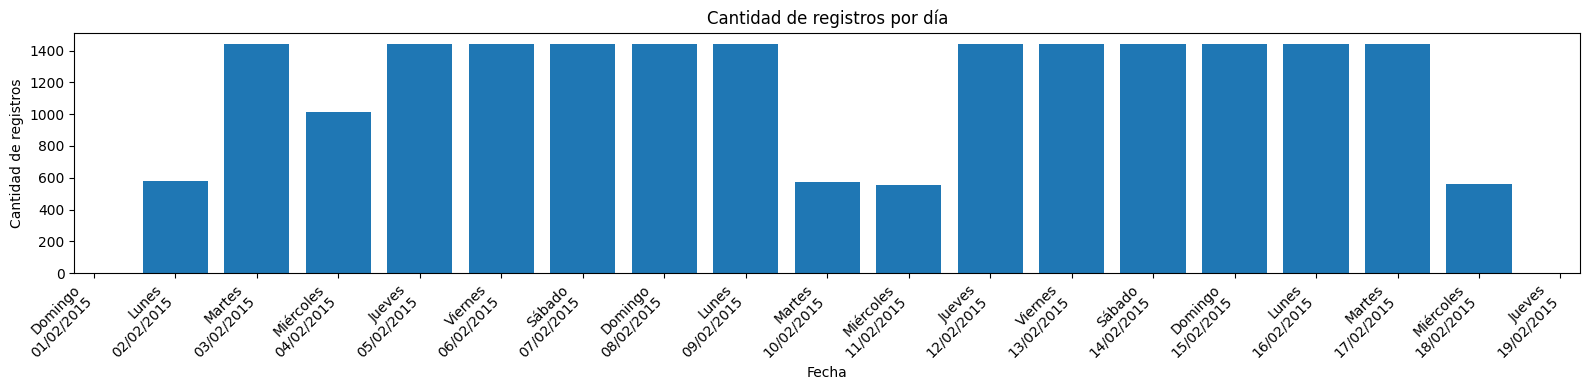

In [ ]:
dias_semana = {
    "Monday": "Lunes",
    "Tuesday": "Martes",
    "Wednesday": "Miércoles",
    "Thursday": "Jueves",
    "Friday": "Viernes",
    "Saturday": "Sábado",
    "Sunday": "Domingo",
}

fig, ax = plt.subplots(figsize=(16, 4))

ax.bar(
    registros_por_dia["fecha"],
    registros_por_dia["cantidad_registros"]
)

ax.set_title("Cantidad de registros por día")
ax.set_xlabel("Fecha")
ax.set_ylabel("Cantidad de registros")

ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

labels = [
    f"{dias_semana[d.strftime('%A')]}\n{d.strftime('%d/%m/%Y')}"
    for d in mdates.num2date(ax.get_xticks())
]

ax.set_xticklabels(labels, rotation=45, ha="right")

plt.tight_layout()
save_figure(fig, "registros_por_dia_con_dia_semana.png")
plt.show()


## 4. Variables temporales para EDA

Se añaden variables derivadas de la fecha para analizar patrones por hora, día de semana y fin de semana. Para el modelo principal se usarán primero solo variables ambientales, evitando depender del calendario.

In [ ]:
def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["hour"] = df["date"].dt.hour
    df["day_of_week"] = df["date"].dt.dayofweek
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    return df


train_df = add_time_features(train_df)
test1_df = add_time_features(test1_df)
test2_df = add_time_features(test2_df)
full_df = add_time_features(full_df)

full_df.head()

,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy,split,hour,day_of_week,is_weekend
0,2015-02-04 17:51:00,23.1800,27.2720,426.0000,721.2500,0.0048,1,train,17,2,0
1,2015-02-04 17:51:59,23.1500,27.2675,429.5000,714.0000,0.0048,1,train,17,2,0
2,2015-02-04 17:53:00,23.1500,27.2450,426.0000,713.5000,0.0048,1,train,17,2,0
3,2015-02-04 17:54:00,23.1500,27.2000,426.0000,708.2500,0.0048,1,train,17,2,0
4,2015-02-04 17:55:00,23.1000,27.2000,426.0000,704.5000,0.0048,1,train,17,2,0


In [ ]:
# =========================
# Ocupación por hora solo en días de semana
# =========================

full_df["date"] = pd.to_datetime(full_df["date"], errors="coerce")

# Crear variables temporales
full_df["hour"] = full_df["date"].dt.hour
full_df["day_of_week"] = full_df["date"].dt.dayofweek  # lunes=0, domingo=6

# Filtrar solo días de semana: lunes a viernes
weekday_df = full_df[full_df["day_of_week"].between(0, 4)].copy()

# Agrupar por hora
occupancy_by_hour_weekdays = (
    weekday_df
    .groupby("hour")
    .agg(
        total_registros=("Occupancy", "count"),
        registros_ocupados=("Occupancy", "sum"),
        registros_no_ocupados=("Occupancy", lambda x: (x == 0).sum()),
        proporcion_ocupacion=("Occupancy", "mean")
    )
    .reset_index()
)

display(occupancy_by_hour_weekdays)

,hour,total_registros,registros_ocupados,registros_no_ocupados,proporcion_ocupacion
0,0,660,0,660,0.0000
1,1,671,0,671,0.0000
2,2,649,0,649,0.0000
3,3,660,0,660,0.0000
4,4,671,0,671,0.0000
5,5,649,0,649,0.0000
6,6,660,0,660,0.0000
7,7,671,72,599,0.1073
8,8,649,315,334,0.4854
9,9,594,578,16,0.9731


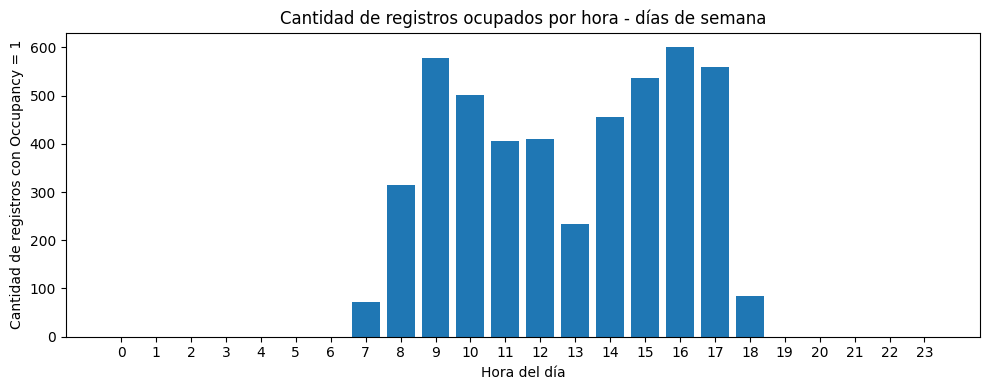

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(
    occupancy_by_hour_weekdays["hour"],
    occupancy_by_hour_weekdays["registros_ocupados"]
)

ax.set_title("Cantidad de registros ocupados por hora - días de semana")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Cantidad de registros con Occupancy = 1")
ax.set_xticks(range(0, 24))

plt.tight_layout()
save_figure(fig, "ocupacion_por_hora_dias_semana.png")
plt.show()


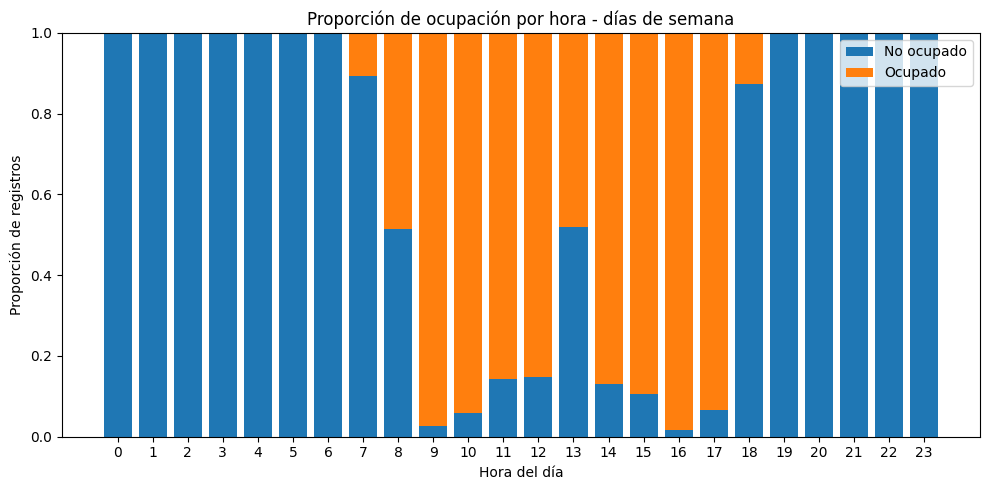

PosixPath('/content/drive/MyDrive/simarro-cursoia/caso-d-uci/outputs_uci_occupancy/tables/ocupacion_por_hora_dias_semana.csv')

In [ ]:
# =========================
# Barras apiladas proporcionales por hora
# Días de semana
# =========================

occupancy_by_hour_weekdays["prop_ocupado"] = (
    occupancy_by_hour_weekdays["registros_ocupados"] /
    occupancy_by_hour_weekdays["total_registros"]
)

occupancy_by_hour_weekdays["prop_no_ocupado"] = (
    occupancy_by_hour_weekdays["registros_no_ocupados"] /
    occupancy_by_hour_weekdays["total_registros"]
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    occupancy_by_hour_weekdays["hour"],
    occupancy_by_hour_weekdays["prop_no_ocupado"],
    label="No ocupado"
)

ax.bar(
    occupancy_by_hour_weekdays["hour"],
    occupancy_by_hour_weekdays["prop_ocupado"],
    bottom=occupancy_by_hour_weekdays["prop_no_ocupado"],
    label="Ocupado"
)

ax.set_title("Proporción de ocupación por hora - días de semana")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Proporción de registros")
ax.set_xticks(range(0, 24))
ax.set_ylim(0, 1)

ax.legend()

plt.tight_layout()
save_figure(fig, "proporcion_ocupacion_por_hora_dias_semana.png")
plt.show()

save_table(occupancy_by_hour_weekdays, "ocupacion_por_hora_dias_semana.csv")


## 5. Estadística descriptiva

Resumen estadístico de las variables numéricas.

In [ ]:
numeric_columns = [
    "Temperature",
    "Humidity",
    "Light",
    "CO2",
    "HumidityRatio",
    "hour",
    "day_of_week",
    "is_weekend",
    "Occupancy",
]

descriptive_stats = full_df[numeric_columns].describe().T.reset_index().rename(columns={"index": "variable"})
save_table(descriptive_stats, "estadistica_descriptiva.csv")
display(descriptive_stats)


,variable,count,mean,std,min,25%,50%,75%,max
0,Temperature,20560.0000,20.9062,1.0553,19.0000,20.2000,20.7000,21.5250,24.4083
1,Humidity,20560.0000,27.6559,4.9822,16.7450,24.5000,27.2900,31.2900,39.5000
2,Light,20560.0000,130.7566,210.4309,0.0000,0.0000,0.0000,301.0000,1697.2500
3,CO2,20560.0000,690.5533,311.2013,412.7500,460.0000,565.4167,804.6667,2076.5000
4,HumidityRatio,20560.0000,0.0042,0.0008,0.0027,0.0037,0.0043,0.0048,0.0065
5,hour,20560.0000,11.4469,7.0758,0.0000,5.0000,11.0000,18.0000,23.0000
6,day_of_week,20560.0000,2.8961,2.0593,0.0000,1.0000,3.0000,5.0000,6.0000
7,is_weekend,20560.0000,0.2802,0.4491,0.0000,0.0000,0.0000,1.0000,1.0000
8,Occupancy,20560.0000,0.2310,0.4215,0.0000,0.0000,0.0000,0.0000,1.0000


## 6. Balance de clases

Se revisa el balanceo de las clases del dataset. Si hubiera muchas más muestras de una clase que de otra, `accuracy` podría ser engañosa.

,split,Occupancy,count,percentage
0,test1,0,1693,63.5272
1,test1,1,972,36.4728
2,test2,0,7703,78.9889
3,test2,1,2049,21.0111
4,train,0,6414,78.7670
5,train,1,1729,21.2330


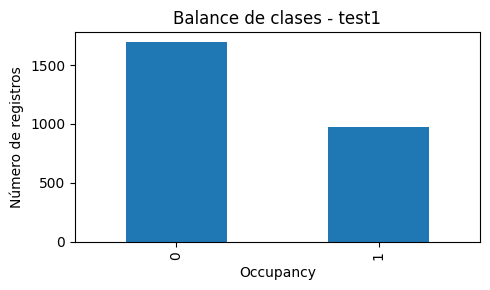

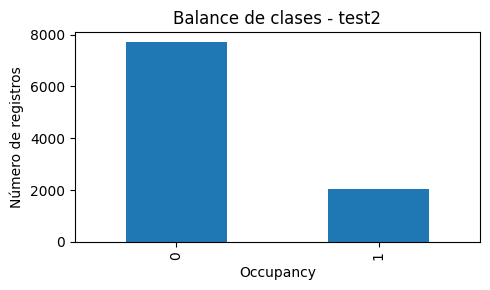

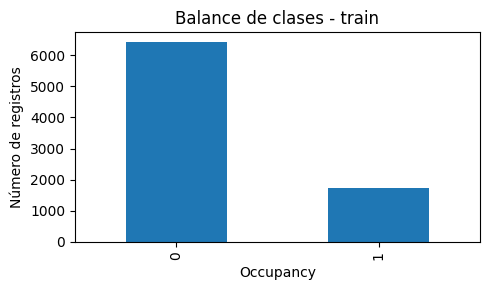

In [ ]:
class_balance = (
    full_df.groupby(["split", "Occupancy"])
    .size()
    .reset_index(name="count")
)
class_balance["percentage"] = class_balance.groupby("split")["count"].transform(
    lambda x: x / x.sum() * 100
)

save_table(class_balance, "balance_clases.csv")
display(class_balance)

for split_name, group in full_df.groupby("split"):
    counts = group["Occupancy"].value_counts().sort_index()
    ax = counts.plot(kind="bar", figsize=(5, 3), title=f"Balance de clases - {split_name}")
    ax.set_xlabel("Occupancy")
    ax.set_ylabel("Número de registros")
    plt.tight_layout()
    save_figure(ax.get_figure(), f"balance_clases_{safe_filename(split_name)}.png")
    plt.show()


## 7. Distribución de variables ambientales

Se revisa la distribución de cada variable. Esto ayuda a detectar rangos anómalos y a entender qué sensores pueden separar mejor la ocupación.

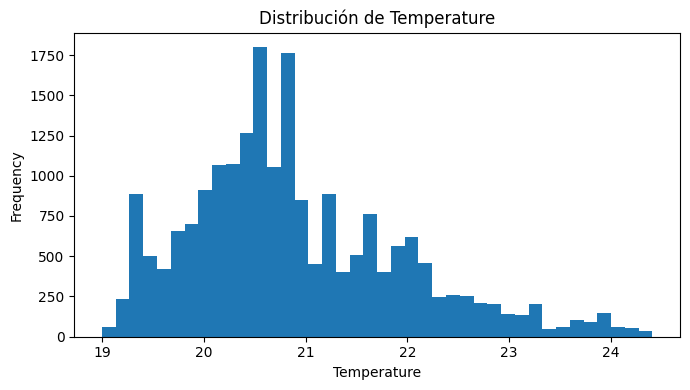

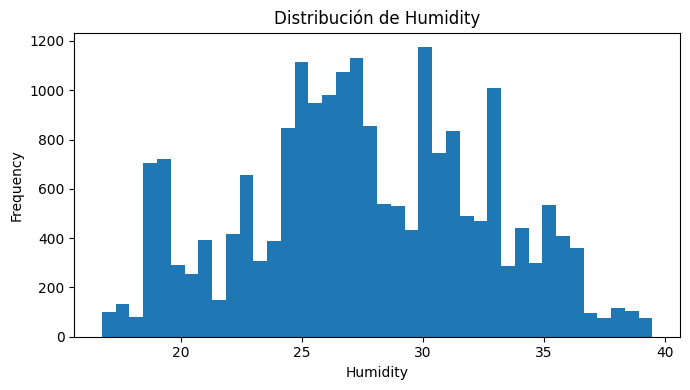

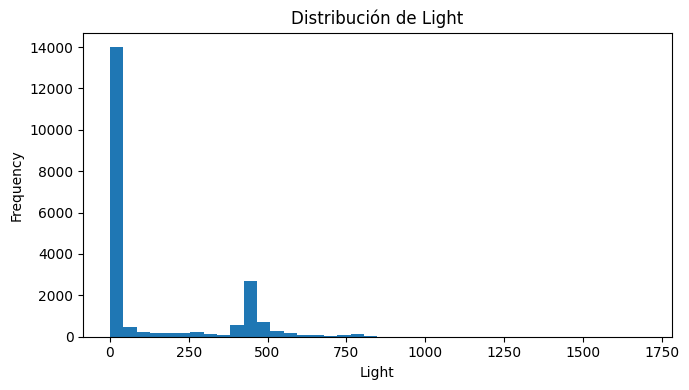

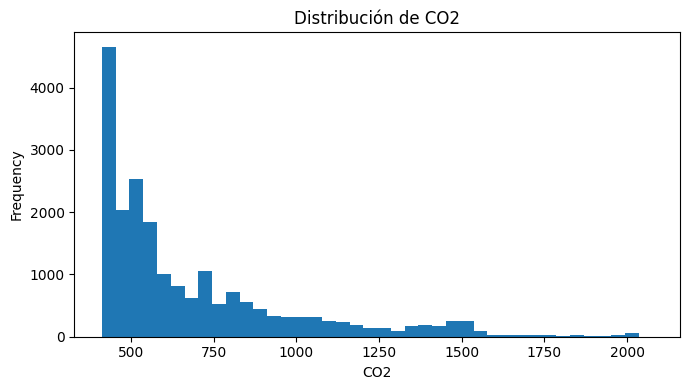

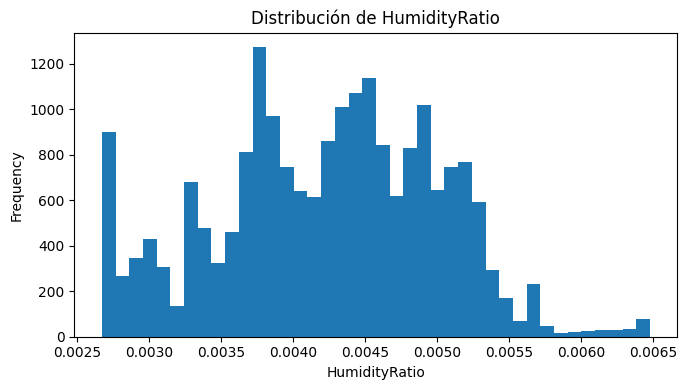

In [ ]:
feature_columns = ["Temperature", "Humidity", "Light", "CO2", "HumidityRatio"]

"""
- `co2` — concentración de CO₂ (ppm) — predictor principal de ocupación
- `temperature-indoor` — temperatura interior (°C)
- `relative-humidity` — humedad relativa (%)
- `avg-sound-level` — nivel de ruido (dB)
- `luminosity` — luminosidad (lux)
"""

for column in feature_columns:
    ax = full_df[column].plot(
        kind="hist",
        bins=40,
        figsize=(7, 4),
        title=f"Distribución de {column}",
    )
    ax.set_xlabel(column)
    plt.tight_layout()
    save_figure(ax.get_figure(), f"distribucion_{safe_filename(column)}.png")
    plt.show()


## 8. Comparación de variables según ocupación

Se comparan las distribuciones de cada variable para `Occupancy = 0` y `Occupancy = 1`.

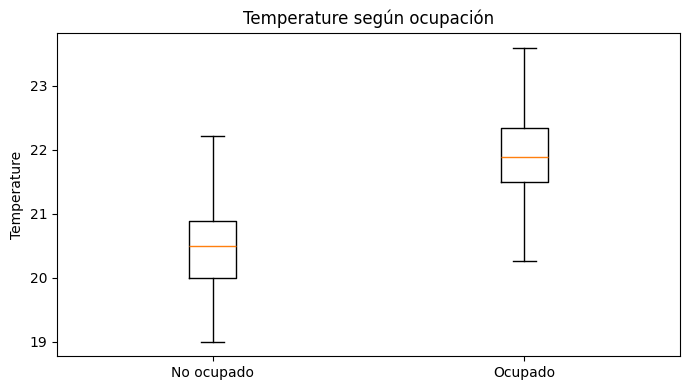

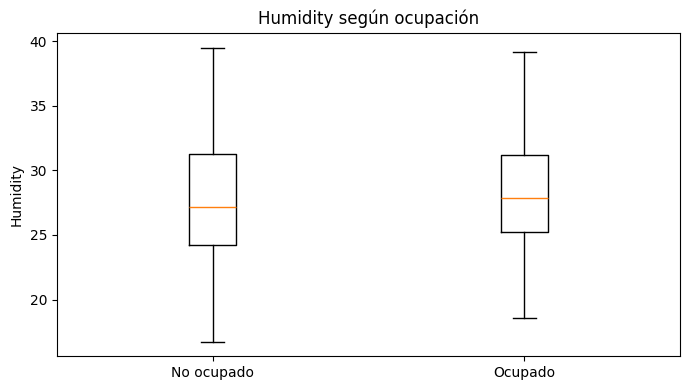

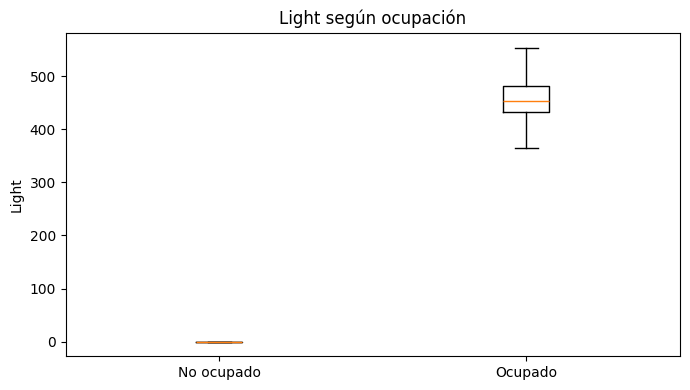

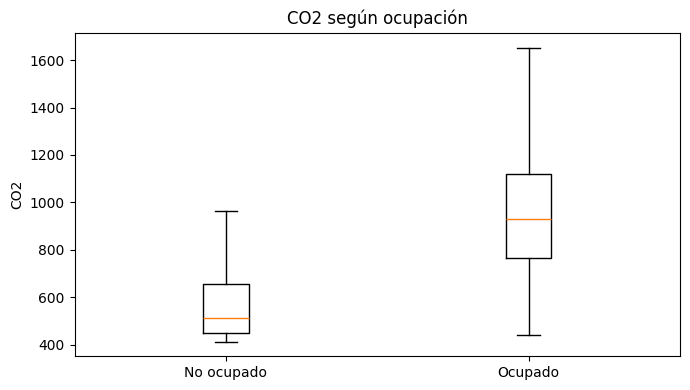

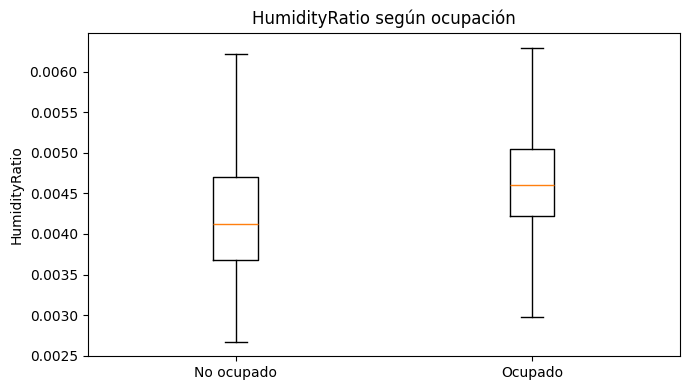

In [ ]:
for column in feature_columns:
    data_to_plot = [
        full_df.loc[full_df["Occupancy"] == 0, column],
        full_df.loc[full_df["Occupancy"] == 1, column],
    ]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.boxplot(data_to_plot, labels=["No ocupado", "Ocupado"], showfliers=False)
    ax.set_title(f"{column} según ocupación")
    ax.set_ylabel(column)
    plt.tight_layout()
    save_figure(fig, f"boxplot_{safe_filename(column)}_segun_ocupacion.png")
    plt.show()


De este primer análisis ya se pueden ver relaciones calras entre ocupación y C02 y fundamentalmente Luz y ocupación.
Por otro lado la tempratura sube cuando hay ocupación, mientras que la humedad se mantiene mas estable.

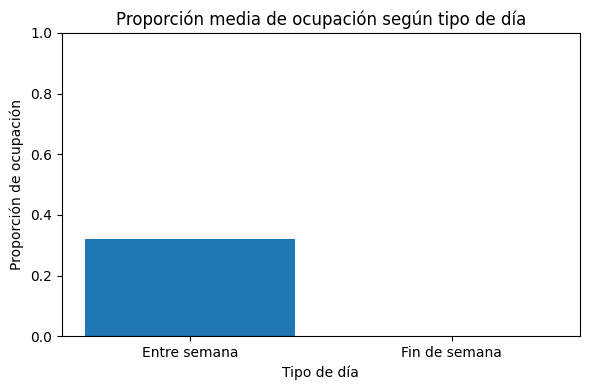

,is_weekend,weekend_label,Occupancy
0,0,Entre semana,0.3209
1,1,Fin de semana,0.0000


In [ ]:
full_df["date"] = pd.to_datetime(full_df["date"], errors="coerce")

full_df["day_of_week"] = full_df["date"].dt.dayofweek
full_df["is_weekend"] = full_df["day_of_week"].isin([5, 6]).astype(int)

dias_semana = {
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo",
}

full_df["day_name"] = full_df["day_of_week"].map(dias_semana)
full_df["weekend_label"] = full_df["is_weekend"].map({
    0: "Entre semana",
    1: "Fin de semana"
})

occupancy_by_weekend = (
    full_df
    .groupby(["is_weekend", "weekend_label"])["Occupancy"]
    .mean()
    .reset_index()
    .sort_values("is_weekend")
)

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    occupancy_by_weekend["weekend_label"],
    occupancy_by_weekend["Occupancy"]
)

ax.set_title("Proporción media de ocupación según tipo de día")
ax.set_xlabel("Tipo de día")
ax.set_ylabel("Proporción de ocupación")
ax.set_ylim(0, 1)

plt.tight_layout()
save_figure(fig, "ocupacion_media_tipo_dia.png")
plt.show()

save_table(occupancy_by_weekend, "ocupacion_media_tipo_dia.csv")
display(occupancy_by_weekend)


Este dato es importante para evaluar que variables son más relevantes para el modelo. Ya que el tipo de día parece ser muy importante para la ocupación, aunque no es una variable que venga de sensorica.

## 9. Evolución temporal de las variables

Se visualizan las variables principales frente al tiempo en una muestra del dataset completo. Esto ayuda a observar la dinámica de CO₂, luz y ocupación.

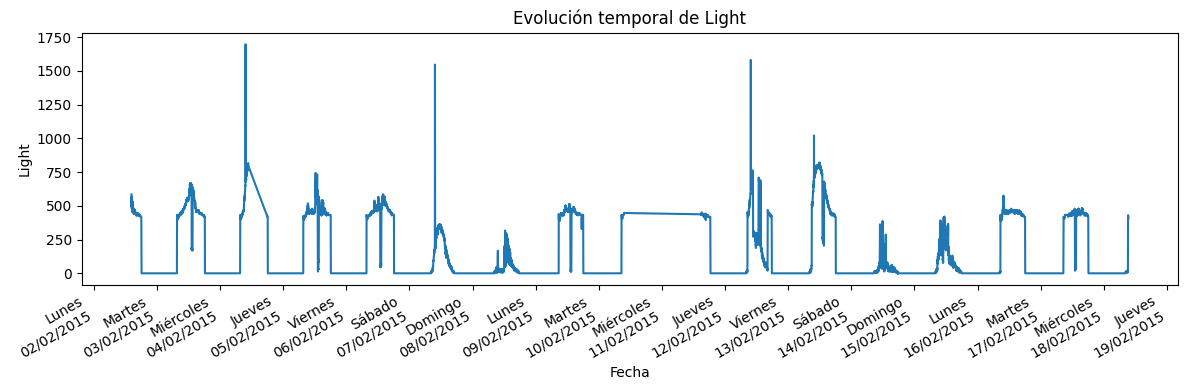

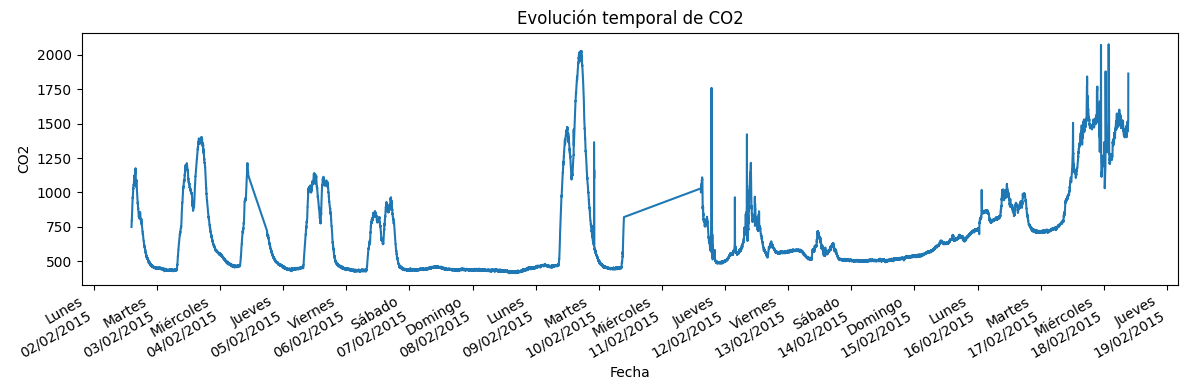

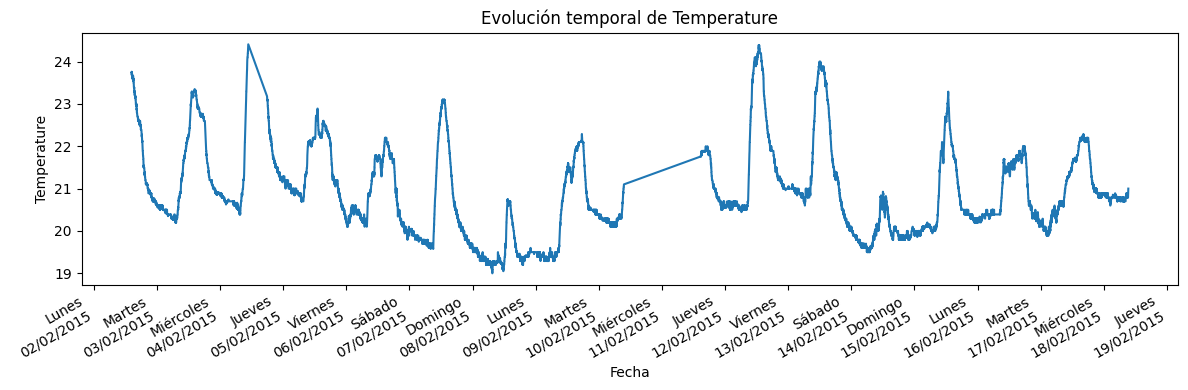

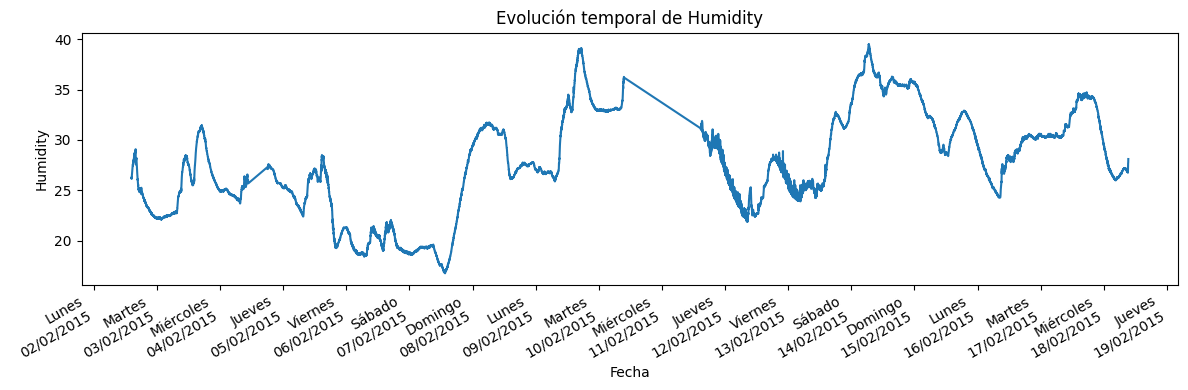

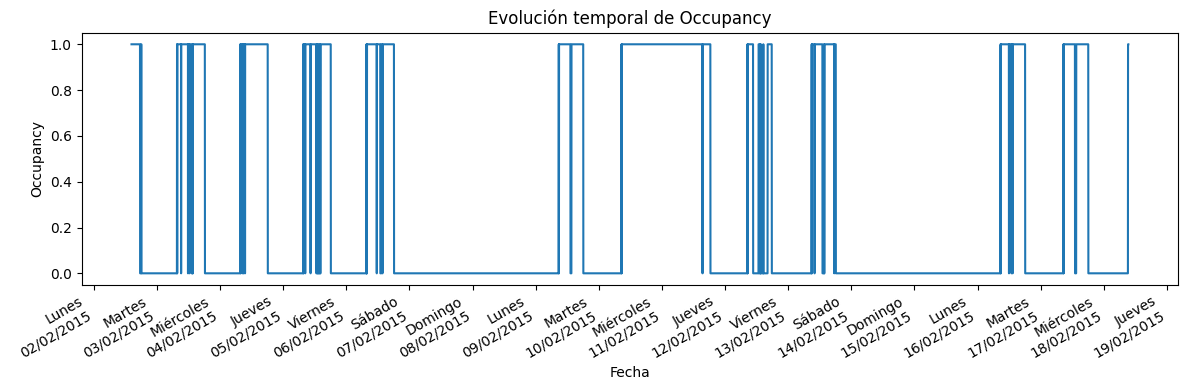

In [ ]:
"""
plot_df = full_df.sort_values("date").copy()

# Para que el gráfico sea legible, tomamos una muestra temporal limitada.
plot_df = plot_df.iloc[: min(2500, len(plot_df))]

for column in ["Light", "CO2", "Temperature", "Humidity", "Occupancy"]:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(plot_df["date"], plot_df[column])
    ax.set_title(f"Evolución temporal de {column}")
    ax.set_xlabel("Fecha")
    ax.set_ylabel(column)
    plt.xticks(rotation=30)
    plt.tight_layout()
    save_figure(fig, f"evolucion_temporal_{safe_filename(column)}.png")
    plt.show()
"""
import matplotlib.dates as mdates

plot_df = full_df.sort_values("date").copy()

# Para que el gráfico sea legible, tomamos una muestra temporal limitada.
#  plot_df = plot_df.iloc[: min(2500, len(plot_df))]

# Diccionario para traducir días de la semana
dias_semana = {
    "Monday": "Lunes",
    "Tuesday": "Martes",
    "Wednesday": "Miércoles",
    "Thursday": "Jueves",
    "Friday": "Viernes",
    "Saturday": "Sábado",
    "Sunday": "Domingo",
}

for column in ["Light", "CO2", "Temperature", "Humidity", "Occupancy"]:
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(plot_df["date"], plot_df[column])

    ax.set_title(f"Evolución temporal de {column}")
    ax.set_xlabel("Fecha")
    ax.set_ylabel(column)

    # Formato del eje X
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

    labels = [
        f"{dias_semana[d.strftime('%A')]}\n{d.strftime('%d/%m/%Y')}"
        for d in mdates.num2date(ax.get_xticks())
    ]

    ax.set_xticklabels(labels, rotation=30, ha="right")

    plt.tight_layout()
    save_figure(fig, f"evolucion_temporal_{safe_filename(column)}.png")
    plt.show()


## 10. Matriz de correlación

La matriz de correlación permite detectar relaciones lineales entre variables. La correlación con `Occupancy` es útil como primera aproximación, aunque no sustituye al entrenamiento de modelos.

,Temperature,Humidity,Light,CO2,HumidityRatio,hour,day_of_week,is_weekend,Occupancy
Temperature,1.0000,-0.1570,0.6890,0.4500,0.2050,0.2360,-0.2430,-0.4120,0.5560
Humidity,-0.1570,1.0000,-0.0290,0.3000,0.9330,0.1150,-0.0460,0.2160,0.0460
Light,0.6890,-0.0290,1.0000,0.4480,0.2230,0.0940,-0.1880,-0.2670,0.9150
CO2,0.4500,0.3000,0.4480,1.0000,0.4780,0.1270,-0.4690,-0.3730,0.5020
HumidityRatio,0.2050,0.9330,0.2230,0.4780,1.0000,0.2020,-0.1490,0.0520,0.2570
hour,0.2360,0.1150,0.0940,0.1270,0.2020,1.0000,-0.0110,0.0040,0.1030
day_of_week,-0.2430,-0.0460,-0.1880,-0.4690,-0.1490,-0.0110,1.0000,0.7890,-0.2850
is_weekend,-0.4120,0.2160,-0.2670,-0.3730,0.0520,0.0040,0.7890,1.0000,-0.3420
Occupancy,0.5560,0.0460,0.9150,0.5020,0.2570,0.1030,-0.2850,-0.3420,1.0000


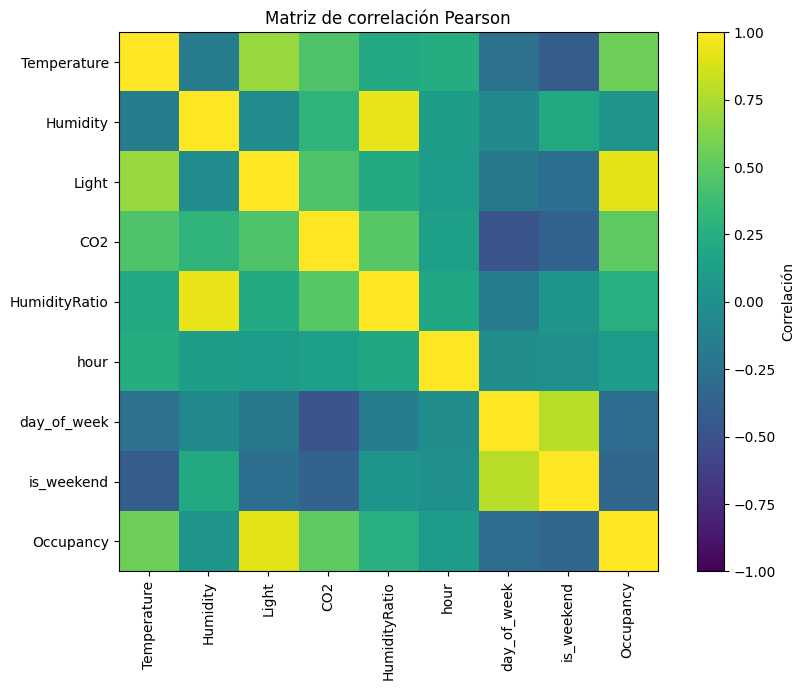

Correlación con Occupancy:


,variable,correlation_with_occupancy
0,Light,0.9148
1,Temperature,0.5556
2,CO2,0.5016
3,is_weekend,-0.3419
4,day_of_week,-0.2846
5,HumidityRatio,0.2573
6,hour,0.1031
7,Humidity,0.0462


In [ ]:
corr_columns = feature_columns + ["hour", "day_of_week", "is_weekend", "Occupancy"]
corr_matrix = full_df[corr_columns].corr(method="pearson")

save_table(corr_matrix.round(6).reset_index().rename(columns={"index": "variable"}), "matriz_correlacion.csv")
display(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_columns)))
ax.set_yticks(range(len(corr_columns)))
ax.set_xticklabels(corr_columns, rotation=90)
ax.set_yticklabels(corr_columns)
ax.set_title("Matriz de correlación Pearson")
fig.colorbar(im, ax=ax, label="Correlación")
plt.tight_layout()
save_figure(fig, "matriz_correlacion.png")
plt.show()

corr_with_target = (
    corr_matrix["Occupancy"]
    .drop("Occupancy")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

corr_with_target_df = corr_with_target.to_frame("correlation_with_occupancy").reset_index().rename(columns={"index": "variable"})
save_table(corr_with_target_df, "correlacion_con_occupancy.csv")
print("Correlación con Occupancy:")
display(corr_with_target_df)


## 11. Preparación para Machine Learning

Se entrena con `datatraining.txt` y se evalúa en:

- `datatest.txt`
- `datatest2.txt`
- test combinado (`datatest + datatest2`)

El modelo principal usa solo variables ambientales:

- `Temperature`
- `Humidity`
- `Light`
- `CO2`
- `HumidityRatio`

In [ ]:
TARGET = "Occupancy"
SENSOR_FEATURES = ["Temperature", "Humidity", "Light", "CO2", "HumidityRatio"]
TIME_FEATURES = ["hour", "day_of_week", "is_weekend"]

X_train = train_df[SENSOR_FEATURES]
y_train = train_df[TARGET]

X_test1 = test1_df[SENSOR_FEATURES]
y_test1 = test1_df[TARGET]

X_test2 = test2_df[SENSOR_FEATURES]
y_test2 = test2_df[TARGET]

test_combined_df = pd.concat([test1_df, test2_df], ignore_index=True)
X_test_combined = test_combined_df[SENSOR_FEATURES]
y_test_combined = test_combined_df[TARGET]

print("Features usadas:", SENSOR_FEATURES)
print("X_train:", X_train.shape)
print("X_test1:", X_test1.shape)
print("X_test2:", X_test2.shape)
print("X_test_combined:", X_test_combined.shape)

Features usadas: ['Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio']
X_train: (8143, 5)
X_test1: (2665, 5)
X_test2: (9752, 5)
X_test_combined: (12417, 5)


## 12. Definición de modelos

Se comparan varios modelos clásicos:

- **DummyClassifier**: baseline simple.
- **Regresión Logística**: modelo lineal interpretable.
- **SVM**: clasificador de margen máximo.
- **Random Forest**: modelo robusto basado en árboles.
- **Gradient Boosting**: modelo ensemble secuencial.

La baseline es obligatoria para comparar si los modelos realmente aportan valor.

In [ ]:
models = {
    "Baseline_MostFrequent": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "model",
                LogisticRegression(
                    max_iter=1000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "SVM_RBF": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "model",
                SVC(
                    kernel="rbf",
                    probability=True,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

models

{'Baseline_MostFrequent': DummyClassifier(strategy='most_frequent'),
 'LogisticRegression': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model',
                  LogisticRegression(class_weight='balanced', max_iter=1000,
                                     random_state=42))]),
 'SVM_RBF': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model',
                  SVC(class_weight='balanced', probability=True,
                      random_state=42))]),
 'RandomForest': RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                        n_estimators=300, n_jobs=-1, random_state=42),
 'GradientBoosting': GradientBoostingClassifier(random_state=42)}

## 13. Funciones de evaluación

In [ ]:
def get_positive_class_score(model, X: pd.DataFrame) -> np.ndarray:
    """Devuelve la probabilidad o score de la clase positiva."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return model.predict(X)


def evaluate_model(model, X: pd.DataFrame, y: pd.Series, dataset_name: str) -> dict:
    y_pred = model.predict(X)
    y_score = get_positive_class_score(model, X)

    metrics = {
        "dataset": dataset_name,
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred, zero_division=0),
        "auc_roc": roc_auc_score(y, y_score),
    }
    return metrics


def evaluate_on_all_tests(model, model_name: str) -> list[dict]:
    rows = []
    for dataset_name, X, y in [
        ("test1", X_test1, y_test1),
        ("test2", X_test2, y_test2),
        ("test_combined", X_test_combined, y_test_combined),
    ]:
        row = evaluate_model(model, X, y, dataset_name)
        row["model"] = model_name
        rows.append(row)
    return rows

## 14. Entrenamiento y comparación de modelos

In [ ]:
results = []
trained_models = {}

for model_name, model in models.items():
    print(f"Entrenando {model_name}...")
    model.fit(X_train, y_train)
    trained_models[model_name] = model
    results.extend(evaluate_on_all_tests(model, model_name))

results_df = pd.DataFrame(results)
results_df = results_df[
    ["model", "dataset", "accuracy", "precision", "recall", "f1", "auc_roc"]
].sort_values(["dataset", "f1"], ascending=[True, False])

results_df.to_csv(TABLES_DIR / "model_results_sensor_features.csv", index=False)
display(results_df)


Entrenando Baseline_MostFrequent...
Entrenando LogisticRegression...
Entrenando SVM_RBF...
Entrenando RandomForest...
Entrenando GradientBoosting...


,model,dataset,accuracy,precision,recall,f1,auc_roc
3,LogisticRegression,test1,0.9786,0.9463,0.9979,0.9715,0.9921
6,SVM_RBF,test1,0.9700,0.9264,0.9969,0.9604,0.9864
12,GradientBoosting,test1,0.9437,0.9448,0.8981,0.9209,0.9897
9,RandomForest,test1,0.9343,0.9433,0.8724,0.9065,0.9866
0,Baseline_MostFrequent,test1,0.6353,0.0000,0.0000,0.0000,0.5000
4,LogisticRegression,test2,0.9916,0.9668,0.9941,0.9803,0.9958
7,SVM_RBF,test2,0.9597,0.8410,0.9966,0.9122,0.9949
10,RandomForest,test2,0.9605,0.8810,0.9390,0.9090,0.9930
13,GradientBoosting,test2,0.9494,0.9502,0.8014,0.8695,0.9696
1,Baseline_MostFrequent,test2,0.7899,0.0000,0.0000,0.0000,0.5000


## 15. Visualización comparativa de métricas

Se comparan las métricas principales sobre el test combinado.

,model,dataset,accuracy,precision,recall,f1,auc_roc
5,LogisticRegression,test_combined,0.9888,0.9601,0.9954,0.9774,0.9952
8,SVM_RBF,test_combined,0.9619,0.8667,0.9967,0.9272,0.9934
11,RandomForest,test_combined,0.9549,0.8991,0.9176,0.9083,0.9908
14,GradientBoosting,test_combined,0.9482,0.9483,0.8325,0.8867,0.9781
2,Baseline_MostFrequent,test_combined,0.7567,0.0000,0.0000,0.0000,0.5000


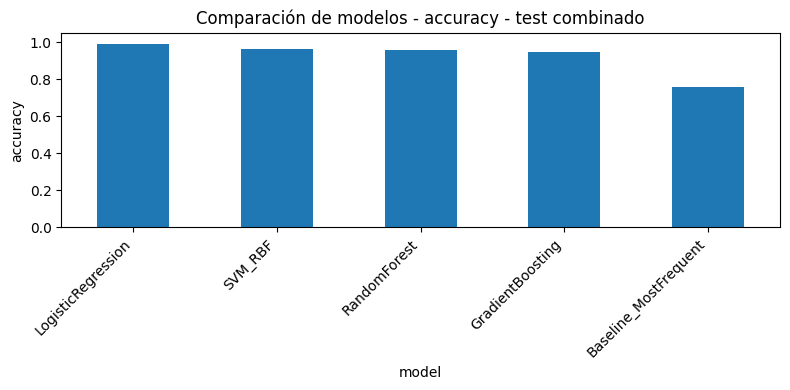

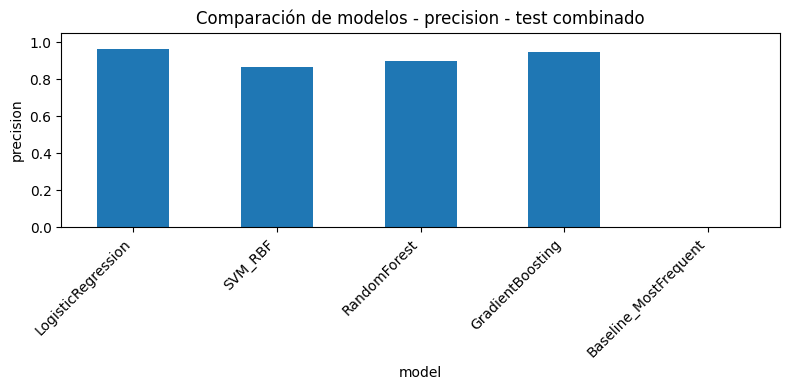

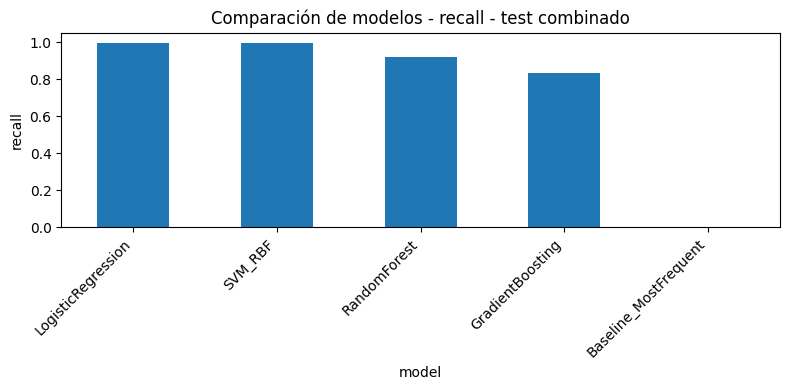

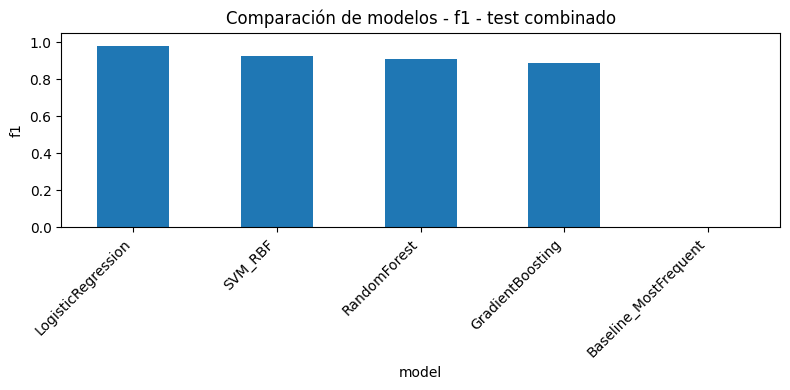

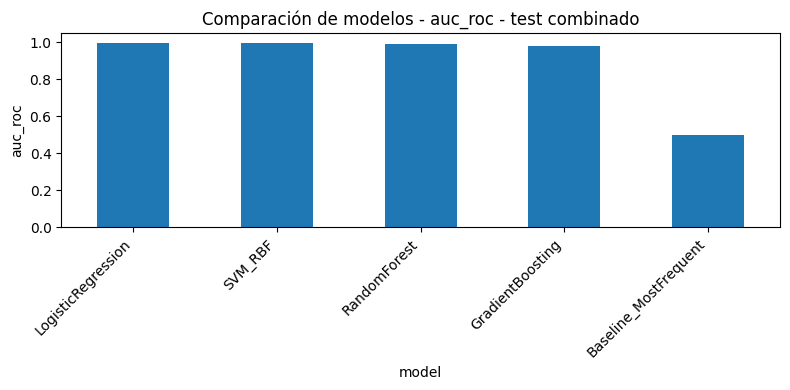

In [ ]:
combined_results = results_df[results_df["dataset"] == "test_combined"].copy()
combined_results = combined_results.sort_values("f1", ascending=False)

save_table(combined_results, "model_results_test_combined_ranking.csv")
display(combined_results)

for metric in ["accuracy", "precision", "recall", "f1", "auc_roc"]:
    ax = combined_results.set_index("model")[metric].plot(
        kind="bar",
        figsize=(8, 4),
        title=f"Comparación de modelos - {metric} - test combinado",
    )
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(metric)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    save_figure(ax.get_figure(), f"comparacion_modelos_{safe_filename(metric)}.png")
    plt.show()


## 16. Selección del mejor modelo

Se selecciona el mejor modelo según `F1-score` en el test combinado. Esta métrica equilibra precision y recall.

In [ ]:
best_row = combined_results.sort_values("f1", ascending=False).iloc[0]
best_model_name = best_row["model"]
best_model = trained_models[best_model_name]

print("Mejor modelo según F1 en test combinado:")
display(best_row.to_frame().T)

print(f"Modelo seleccionado: {best_model_name}")

Mejor modelo según F1 en test combinado:


,model,dataset,accuracy,precision,recall,f1,auc_roc
5,LogisticRegression,test_combined,0.9888,0.9601,0.9954,0.9774,0.9952


Modelo seleccionado: LogisticRegression


## 17. Matriz de confusión y reporte de clasificación

Classification report - test combinado
              precision    recall  f1-score   support

  No ocupado       1.00      0.99      0.99      9396
     Ocupado       0.96      1.00      0.98      3021

    accuracy                           0.99     12417
   macro avg       0.98      0.99      0.98     12417
weighted avg       0.99      0.99      0.99     12417



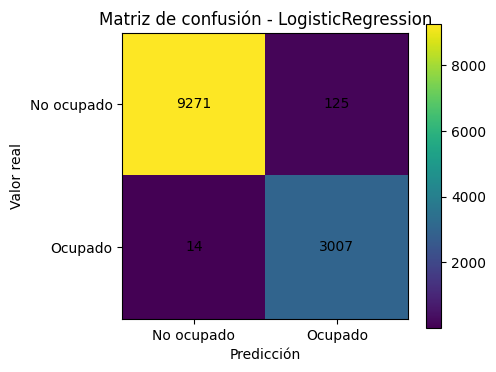

In [ ]:
y_pred_best = best_model.predict(X_test_combined)
cm = confusion_matrix(y_test_combined, y_pred_best)

classification_report_best = classification_report(
    y_test_combined,
    y_pred_best,
    target_names=["No ocupado", "Ocupado"],
    output_dict=True,
)
classification_report_best_df = pd.DataFrame(classification_report_best).T.reset_index().rename(columns={"index": "class"})
save_table(classification_report_best_df, "classification_report_best_model.csv")

cm_df = pd.DataFrame(
    cm,
    index=["real_no_ocupado", "real_ocupado"],
    columns=["pred_no_ocupado", "pred_ocupado"],
).reset_index().rename(columns={"index": "real"})
save_table(cm_df, "confusion_matrix_best_model.csv")

print("Classification report - test combinado")
print(classification_report(y_test_combined, y_pred_best, target_names=["No ocupado", "Ocupado"]))

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)
ax.set_title(f"Matriz de confusión - {best_model_name}")
ax.set_xlabel("Predicción")
ax.set_ylabel("Valor real")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["No ocupado", "Ocupado"])
ax.set_yticklabels(["No ocupado", "Ocupado"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

fig.colorbar(im, ax=ax)
plt.tight_layout()
save_figure(fig, "confusion_matrix_best_model.png")
plt.show()


Acá se puede ver visualmente que la diagonal de casos de acierto (real vs predicicón) es excelente.

## 18. Curvas ROC

La curva ROC muestra la capacidad del modelo para separar ambas clases a distintos umbrales.

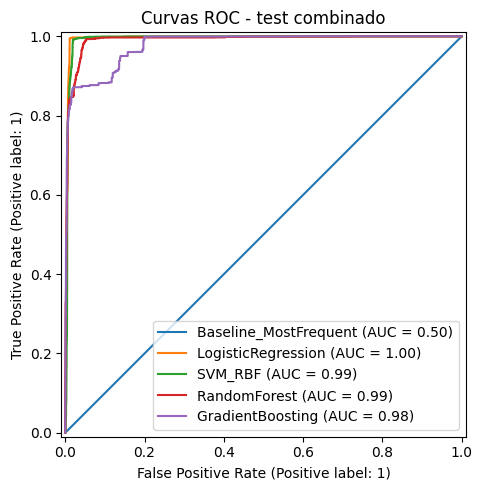

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

for model_name, model in trained_models.items():
    try:
        RocCurveDisplay.from_estimator(
            model,
            X_test_combined,
            y_test_combined,
            name=model_name,
            ax=ax,
        )
    except Exception as exc:
        print(f"No se pudo dibujar ROC para {model_name}: {exc}")

ax.set_title("Curvas ROC - test combinado")
plt.tight_layout()
save_figure(fig, "curvas_roc_test_combinado.png")
plt.show()


## 19. Importancia de variables

Para modelos basados en árboles, se puede analizar la importancia de variables. Esto ayuda a justificar qué sensores aportan más información al modelo.

,feature,importance
0,Light,4.4999
1,CO2,1.8716
2,Temperature,1.2172
3,HumidityRatio,0.0353
4,Humidity,0.0343


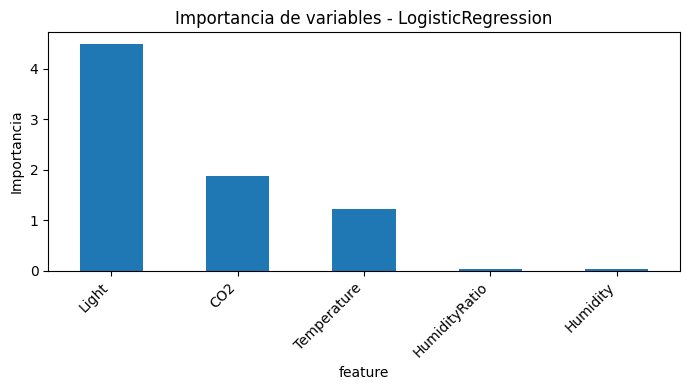

In [ ]:
def get_feature_importance(model, feature_names: list[str]) -> pd.DataFrame | None:
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    elif hasattr(model, "named_steps") and hasattr(model.named_steps.get("model"), "coef_"):
        importances = np.abs(model.named_steps["model"].coef_[0])
    elif hasattr(model, "coef_"):
        importances = np.abs(model.coef_[0])
    else:
        return None

    return (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


importance_df = get_feature_importance(best_model, SENSOR_FEATURES)

if importance_df is not None:
    save_table(importance_df, "feature_importance_best_model.csv")
    display(importance_df)
    ax = importance_df.set_index("feature")["importance"].plot(
        kind="bar",
        figsize=(7, 4),
        title=f"Importancia de variables - {best_model_name}",
    )
    ax.set_ylabel("Importancia")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    save_figure(ax.get_figure(), "feature_importance_best_model.png")
    plt.show()
else:
    print(
        f"El modelo {best_model_name} no expone importancia de variables directamente. "
        "Puedes revisar la correlación con Occupancy o usar permutation importance."
    )


## 21. Guardado de todos los modelos y resultados

Se guardan **todos los modelos probados** en `outputs_uci_occupancy/models/`.

- El mejor modelo según `F1-score` en el test combinado se guarda con prefijo `best_`.
- El resto de modelos se guarda con su nombre normal.
- También se genera un fichero `models_metadata.json` con las rutas, métrica de selección y ranking.



In [ ]:
import json

ensure_output_dirs()

saved_models = {}

for model_name, model in trained_models.items():
    prefix = "best_" if model_name == best_model_name else ""
    filename = f"{prefix}{safe_filename(model_name)}.joblib"
    model_path = MODELS_DIR / filename

    joblib.dump(model, model_path)

    saved_models[model_name] = {
        "path": str(model_path),
        "is_best": model_name == best_model_name,
    }

metadata = {
    "best_model_name": best_model_name,
    "features": SENSOR_FEATURES,
    "target": TARGET,
    "selection_metric": "f1 on test_combined",
    "output_dir": str(OUTPUT_DIR),
    "tables_dir": str(TABLES_DIR),
    "figures_dir": str(FIGURES_DIR),
    "models_dir": str(MODELS_DIR),
    "models": saved_models,
    "ranking_test_combined": combined_results.to_dict(orient="records"),
}

metadata_path = OUTPUT_DIR / "models_metadata.json"

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

artifacts_manifest = {
    "output_dir": str(OUTPUT_DIR),
    "tables": sorted(str(path) for path in TABLES_DIR.glob("*.csv")),
    "figures": sorted(str(path) for path in FIGURES_DIR.glob("*.png")),
    "models": sorted(str(path) for path in MODELS_DIR.glob("*.joblib")),
    "metadata": str(metadata_path),
}

manifest_path = OUTPUT_DIR / "artifacts_manifest.json"
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(artifacts_manifest, f, indent=2, ensure_ascii=False)

print("Modelos guardados:")
for model_name, info in saved_models.items():
    tag = " <-- MEJOR MODELO" if info["is_best"] else ""
    print(f"- {model_name}: {info['path']}{tag}")

print(f"\nMetadata guardada en: {metadata_path}")
print(f"Manifest de artefactos guardado en: {manifest_path}")
print(f"Resultados guardados en Drive: {OUTPUT_DIR.resolve()}")


Modelos guardados:
- Baseline_MostFrequent: /content/drive/MyDrive/simarro-cursoia/caso-d-uci/outputs_uci_occupancy/models/Baseline_MostFrequent.joblib
- LogisticRegression: /content/drive/MyDrive/simarro-cursoia/caso-d-uci/outputs_uci_occupancy/models/best_LogisticRegression.joblib <-- MEJOR MODELO
- SVM_RBF: /content/drive/MyDrive/simarro-cursoia/caso-d-uci/outputs_uci_occupancy/models/SVM_RBF.joblib
- RandomForest: /content/drive/MyDrive/simarro-cursoia/caso-d-uci/outputs_uci_occupancy/models/RandomForest.joblib
- GradientBoosting: /content/drive/MyDrive/simarro-cursoia/caso-d-uci/outputs_uci_occupancy/models/GradientBoosting.joblib

Metadata guardada en: /content/drive/MyDrive/simarro-cursoia/caso-d-uci/outputs_uci_occupancy/models_metadata.json
Manifest de artefactos guardado en: /content/drive/MyDrive/simarro-cursoia/caso-d-uci/outputs_uci_occupancy/artifacts_manifest.json
Resultados guardados en Drive: /content/drive/MyDrive/simarro-cursoia/caso-d-uci/outputs_uci_occupancy


## 22. Conclusiones del caso UCI


- El dataset no presenta una complejidad elevada de limpieza, por lo que es adecuado como MVP del Caso D. Viene muy limpio y preciso.
- La variable objetivo `Occupancy` permite plantear un problema de clasificación binaria supervisada.
- La baseline sirve como referencia mínima: cualquier modelo útil debe superarla claramente, aunque las precisiones obtenidas acá ya son demasiados buenas para seguir iterando con parametrizaciones u otros modelos.
- Las variables ambientales, especialmente luz y CO₂, suelen tener una relación fuerte con la ocupación. La variable luz resulta especialmente predictora.
- Los modelos Random Forest y Gradient Boosting suelen funcionar bien en datos tabulares de sensores.
- El modelo seleccionado puede integrarse posteriormente en una app, dashboard o pipeline de CENTINELA para estimar ocupación sin cámaras ni sensores explícitos de presencia.
- También se abstrae del modelo el día de la semana, ya que con más datos, el modelo podría entrenarse con el conocimiento de que en un fin de semana la ocupacion es siempre 0, y funcionar mal en caso de que haya alguna clase un sábado, por ejemplo.
- Lo mismo para las franjas horarias en donde puede haber un aprendizaje con mucho peso en las franjas horarias, y no en los sensores reales que tiene como objetivo el proyecto CENTINELA.
- No se realiza pruebas con parámetros de los modelos ya que los obtenidos son demasiado precisos, tal vez hasta esten sobreentrenados.